In [1]:
######################## Import Necessary Libraries ###########################
# Required Libraries
import tensorflow as tf
import keras
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from keras.models import Model
from keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import cv2  # for image loading and resizing
import os
#import sklearn

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Keras Module:", tf.keras.__file__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

# GPU Configuration
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

print("Successful!")

2026-01-14 12:33:30.834350: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-14 12:33:30.895475: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-14 12:33:32.238311: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.20.0
Keras: 3.12.0
Keras Module: /home/local2/miniconda3/envs/tf218gpu/lib/python3.10/site-packages/keras/_tf_keras/keras/__init__.py
NumPy: 2.2.6
OpenCV: 4.12.0
Num GPUs Available:  2
Successful!


Processing Images:  64%|██████▍   | 9/14 [00:00<00:00, 39.89it/s]

Processing Image_112620241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_119020241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_120120241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_1202220250919PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_1214920250929PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_1215220250929PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_1215320250929PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_1222720251024PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_125420241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)


Processing Images: 100%|██████████| 14/14 [00:00<00:00, 40.07it/s]


Processing Image_127320241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_134120241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_135020241031PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_682420250621PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Processing Image_686420250623PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088)
Final Image Patches Shape: (1078, 512, 512)
Final Mask Patches Shape: (1078, 512, 512)
Image Patches Shape after expand_dims: (1078, 512, 512, 1)
Mask Patches Shape after expand_dims: (1078, 512, 512, 1)


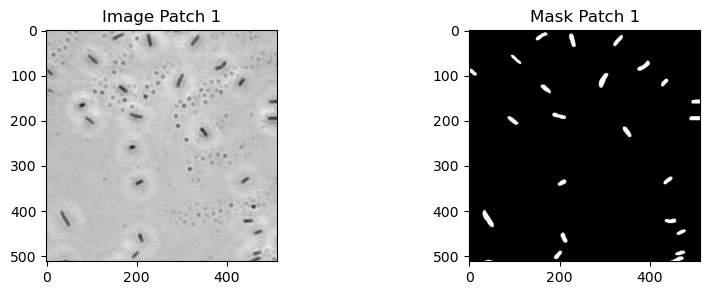

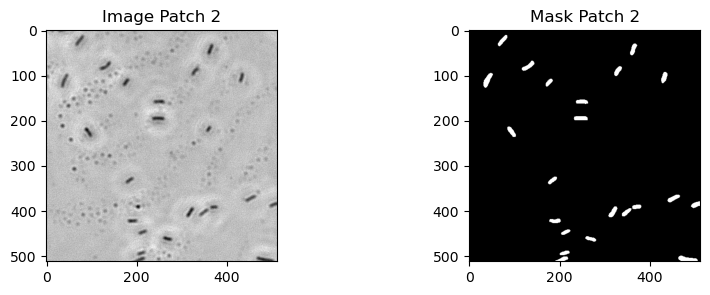

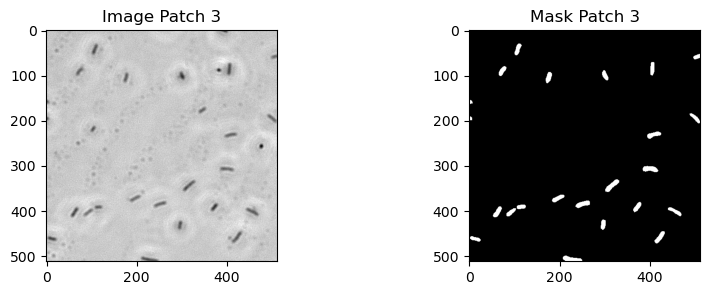

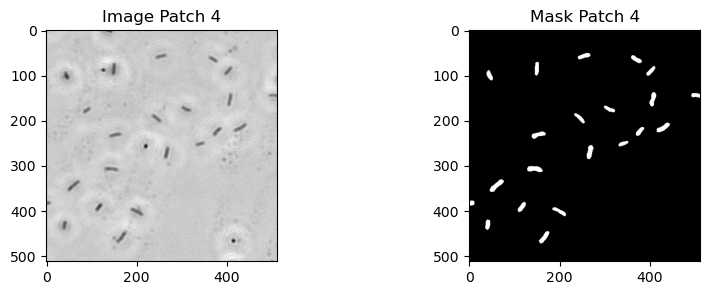

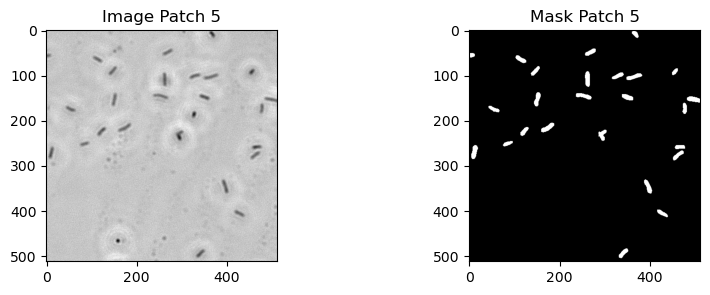

Dataset Loaded Successfully!


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2  # Using OpenCV instead of skimage
from tqdm import tqdm  # For progress tracking

def load_tiff_image(path):
    """Load a TIFF image from the given path."""
    return cv2.imread(path, cv2.IMREAD_UNCHANGED)  # Load with original bit-depth

def extract_patches(image, patch_size=(512, 512), stride=(256, 256)):
    """Extracts patches of a specified size from an image with a given stride."""
    height, width = image.shape[:2]  # Get image dimensions
    
    num_patches_h = (height - patch_size[0]) // stride[0] + 1
    num_patches_w = (width - patch_size[1]) // stride[1] + 1
    
    patches = []
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            y = i * stride[0]
            x = j * stride[1]
            patch = image[y:y + patch_size[0], x:x + patch_size[1]]
            
            if patch.shape[:2] == patch_size:  # Ensure correct shape
                patches.append(patch)
    
    return patches

def load_dataset(image_folder, mask_folder, patch_size=(512, 512), stride=(256, 256)):
    """Load images and masks from folders and extract patches."""
    image_patches, mask_patches = [], []
    
    # Filter only .tif files
    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith('.tif')])
    mask_files = sorted([f for f in os.listdir(mask_folder) if f.endswith('.tif')])
    
    for img_file, mask_file in tqdm(zip(image_files, mask_files), total=len(image_files), desc="Processing Images"):
        img_path = os.path.join(image_folder, img_file)
        mask_path = os.path.join(mask_folder, mask_file)
        
        image = load_tiff_image(img_path)
        mask = load_tiff_image(mask_path)
        
        print(f"Processing {img_file}: Image shape {image.shape}, Mask shape {mask.shape}")
        
        current_image_patches = extract_patches(image, patch_size, stride)
        current_mask_patches = extract_patches(mask, patch_size, stride)
        
        # Ensure patches match in count
        min_patches = min(len(current_image_patches), len(current_mask_patches))
        image_patches.extend(current_image_patches[:min_patches])
        mask_patches.extend(current_mask_patches[:min_patches])
    
    # Convert to NumPy arrays
    image_patches = np.array(image_patches)
    mask_patches = np.array(mask_patches)
    
    print("Final Image Patches Shape:", image_patches.shape)
    print("Final Mask Patches Shape:", mask_patches.shape)
    
    # Ensure grayscale images have a channel dimension
    if image_patches.ndim == 3:
        image_patches = np.expand_dims(image_patches, axis=-1)
        mask_patches = np.expand_dims(mask_patches, axis=-1)
    
    print("Image Patches Shape after expand_dims:", image_patches.shape)
    print("Mask Patches Shape after expand_dims:", mask_patches.shape)
    
    # Ensure masks are binary (0 or 1)
    mask_patches = (mask_patches / 255.0 > 0.5).astype(np.float32)
    
    # Display some patches
    if len(image_patches) > 0 and len(mask_patches) > 0:
        for i in range(min(5, len(image_patches))):
            plt.figure(figsize=(10, 3))
            plt.subplot(1, 2, 1)
            plt.imshow(image_patches[i].squeeze(), cmap='gray')
            plt.title(f"Image Patch {i + 1}")
            plt.subplot(1, 2, 2)
            plt.imshow(mask_patches[i].squeeze(), cmap='gray')
            plt.title(f"Mask Patch {i + 1}")
            plt.show()
    else:
        print("No patches to display.")
    
    return image_patches, mask_patches

# Define paths
image_folder = '/home/local2/huili/Bacteria ID/Sabita/Training data/5th/e coli_need'
mask_folder =  '/home/local2/huili/Bacteria ID/Sabita/Training data/5th/E coli-mask_Need'

# Load dataset
X_train, y_train = load_dataset(image_folder, mask_folder)
print("Dataset Loaded Successfully!")


In [3]:
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate, Dropout
from keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from keras import regularizers

def unet_model(input_size=(512, 512, 1), l2_strength=0.001):
    inputs = Input(input_size)

    # Encoder
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(inputs)
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(conv1)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    pool1 = Dropout(0.5)(pool1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(pool1)
    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(conv2)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    pool2 = Dropout(0.4)(pool2)
    

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(pool2)
    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(conv3)
    conv3 = BatchNormalization()(conv3)

    # Decoder
    up4 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same',
                          kernel_regularizer=regularizers.l2(l2_strength))(conv3)
    up4 = concatenate([up4, conv2], axis=-1)
    conv4 = Conv2D(128, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(up4)
    conv4 = Conv2D(128, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(conv4)
    conv4 = BatchNormalization()(conv4)
    conv4 = Dropout(0.3)(conv4)

    up5 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same',
                          kernel_regularizer=regularizers.l2(l2_strength))(conv4)
    up5 = concatenate([up5, conv1], axis=-1)
    conv5 = Conv2D(64, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(up5)
    conv5 = Conv2D(64, (3, 3), activation='relu', padding='same',
                   kernel_regularizer=regularizers.l2(l2_strength))(conv5)
    conv5 = BatchNormalization()(conv5)
    conv5 = Dropout(0.2)(conv5)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)

    return Model(inputs, outputs)

# Instantiate model
model = unet_model(input_size=(512, 512, 1))

#model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1768415623.949253  538457 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22138 MB memory:  -> device: 0, name: NVIDIA RTX A5500, pci bus id: 0000:ac:00.0, compute capability: 8.6
I0000 00:00:1768415623.951032  538457 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22321 MB memory:  -> device: 1, name: NVIDIA RTX A5500, pci bus id: 0000:ca:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 256, 256,  │    131,200 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │    295,040 │ concatenate[0][0

 Total params: 1,864,257 (7.11 MB)

 Trainable params: 1,862,977 (7.11 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [4]:
import tensorflow as tf

# ---------- IoU (Jaccard) ----------
def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # if your model outputs probabilities (sigmoid), keep y_pred as-is
    # optional: threshold for metric only
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred_bin, axis=[1,2,3]) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return tf.reduce_mean(iou)

# ---------- Soft IoU loss (differentiable) ----------
def soft_iou_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return 1.0 - tf.reduce_mean(iou)

# ---------- Combined loss: BCE + IoU loss ----------
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def bce_plus_iou_loss(y_true, y_pred):
    return bce(y_true, y_pred) + soft_iou_loss(y_true, y_pred)


In [27]:
import tensorflow as tf

# BCE (use sigmoid output -> from_logits=False)
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def dice_coef(y_true, y_pred, smooth=1e-6):
    """
    y_true, y_pred: (N,H,W,1) or (N,H,W)
    returns mean Dice over batch
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # ensure 4D
    if len(y_true.shape) == 3:
        y_true = y_true[..., tf.newaxis]
    if len(y_pred.shape) == 3:
        y_pred = y_pred[..., tf.newaxis]

    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom = tf.reduce_sum(y_true + y_pred, axis=[1, 2, 3])

    dice = (2.0 * intersection + smooth) / (denom + smooth)
    return tf.reduce_mean(dice)

def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1.0 - dice_coef(y_true, y_pred, smooth=smooth)

def bce_plus_dice_loss(y_true, y_pred, alpha=0.5, beta=0.5):
    """
    Combined loss = alpha * BCE + beta * DiceLoss
    Recommended start: alpha=0.5, beta=0.5
    """
    return alpha * bce(y_true, y_pred) + beta * dice_loss(y_true, y_pred)


In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_plus_iou_loss,
    metrics=[iou_coef]
)


In [8]:
ALPHA = 0.5  # BCE weight
BETA  = 0.5  # IoU loss weight

def bce_plus_iou_loss(y_true, y_pred):
    return ALPHA * bce(y_true, y_pred) + BETA * soft_iou_loss(y_true, y_pred)


In [9]:
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=True
)

In [10]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet3.keras",
        monitor="val_iou_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_iou_coef",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_iou_coef",
        mode="max",
        factor=0.5,
        patience=20,
        min_lr=1e-7,
        verbose=1
    )
]

In [21]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_unet3.keras",
        monitor="val_iou_coef", mode="max",
        save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_iou_coef", mode="max",
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_iou_coef", mode="max",
        patience=20,              # must be bigger than 8
        min_delta=0.002,          # require real improvement
        restore_best_weights=True,
        verbose=1
    )
]


Epoch 1/200


2026-01-14 12:34:52.255030: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fa61801d830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-14 12:34:52.255066: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A5500, Compute Capability 8.6
2026-01-14 12:34:52.255072: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA RTX A5500, Compute Capability 8.6
2026-01-14 12:34:52.400217: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-14 12:34:53.044290: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-14 12:34:55.633321: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 33.28GiB with freed_by_count=0. The caller indicates that this 

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - iou_coef: 0.0066 - loss: 2.1460

2026-01-14 12:35:56.649705: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.52GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-14 12:35:56.930900: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 33.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-14 12:36:11.348463: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.23GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-14 12:36:20.517522: I external/local_xla/xla

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - iou_coef: 0.0067 - loss: 2.1445

2026-01-14 12:36:23.124802: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 16.65GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-01-14 12:36:23.633704: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 33.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



Epoch 1: val_iou_coef improved from None to 0.00423, saving model to best_unet3.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 100s 602ms/step - iou_coef: 0.0101 - loss: 1.9773 - val_iou_coef: 0.0042 - val_loss: 1.8189 - learning_rate: 1.0000e-04
Epoch 2/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - iou_coef: 0.0320 - loss: 1.5638
Epoch 2: val_iou_coef improved from 0.00423 to 0.00738, saving model to best_unet3.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 305ms/step - iou_coef: 0.0506 - loss: 1.4642 - val_iou_coef: 0.0074 - val_loss: 1.4348 - learning_rate: 1.0000e-04
Epoch 3/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - iou_coef: 0.1124 - loss: 1.2162
Epoch 3: val_iou_coef improved from 0.00738 to 0.02098, saving model to best_unet3.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 307ms/step - iou_coef: 0.1230 - loss: 1.1577 - val_iou_coef: 0.0210 - val_loss: 1.1905 - learning_rate: 1.0000e-04
Epoch 4/200
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - iou_coef: 0.1625 - loss: 1.0090
Epoch 4: val_iou_coef d

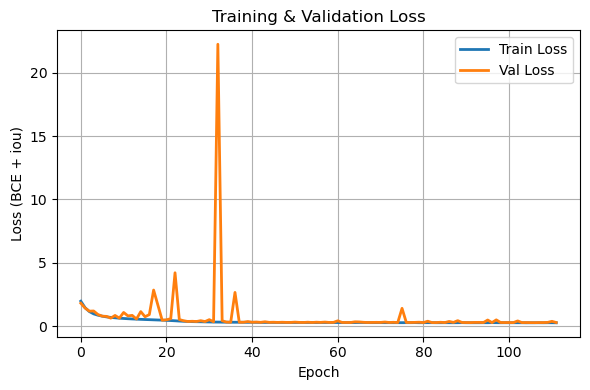

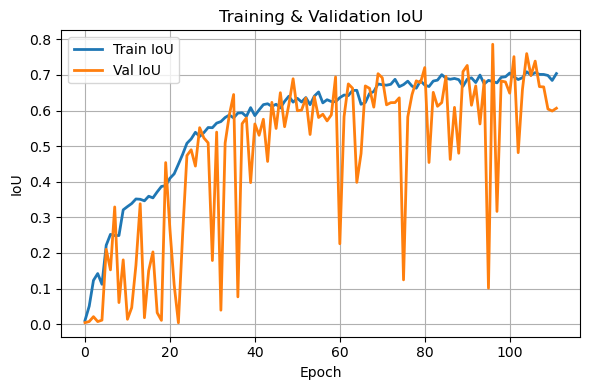

In [11]:
import matplotlib.pyplot as plt
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,   
    shuffle=True,
    callbacks=callbacks
)


# =========================
# 1) Loss vs Epoch
# =========================
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss", linewidth=2)
plt.plot(history.history["val_loss"], label="Val Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE + iou)")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 2) IoU vs Epoch
# =========================
plt.figure(figsize=(6, 4))
plt.plot(history.history["iou_coef"], label="Train IoU", linewidth=2)
plt.plot(history.history["val_iou_coef"], label="Val IoU", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training & Validation IoU")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


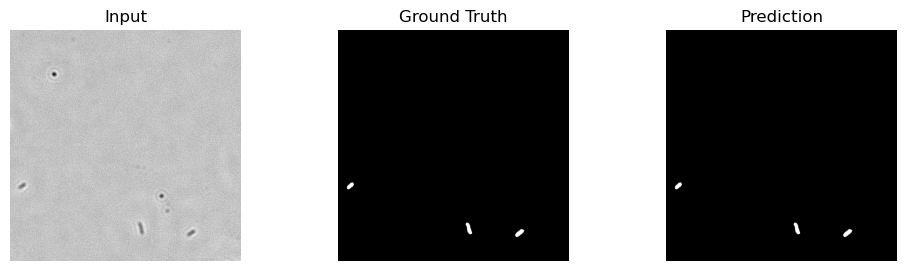

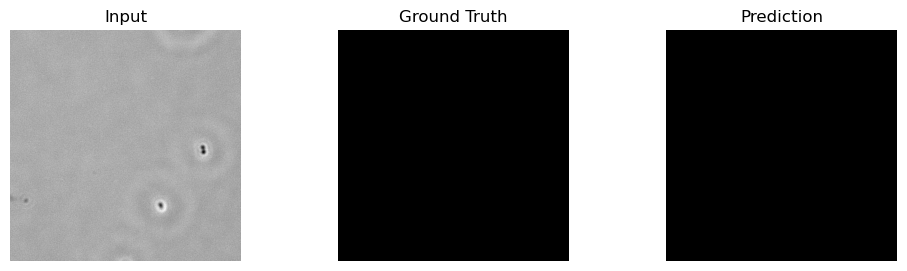

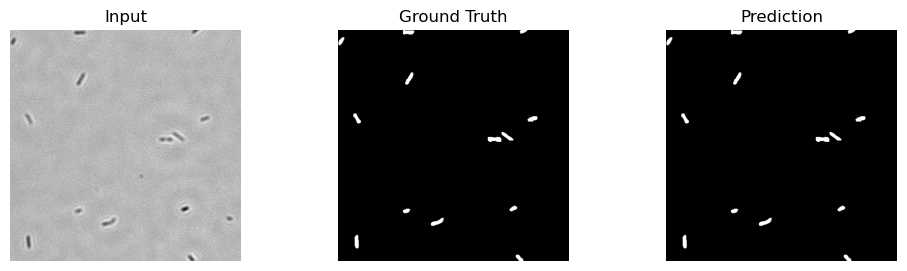

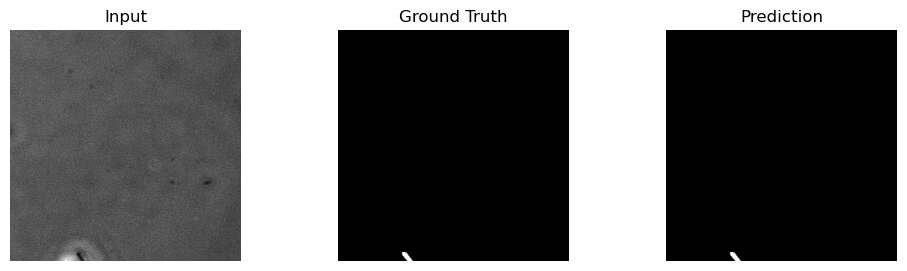

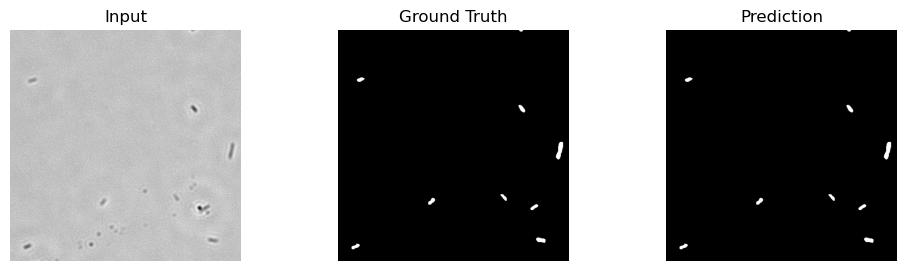

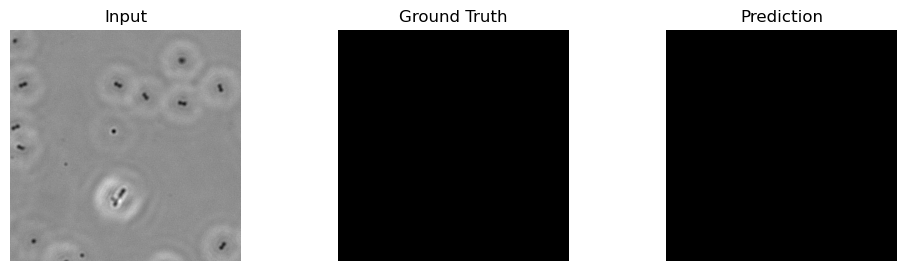

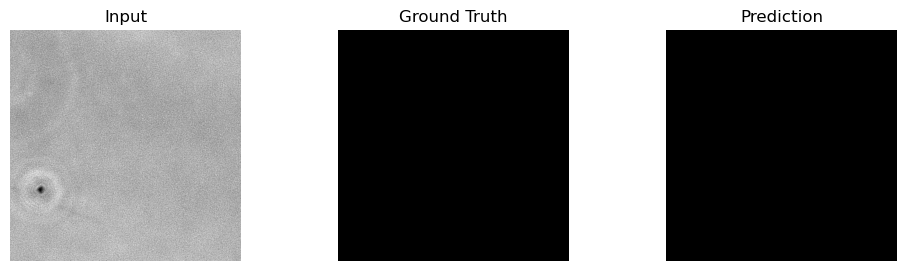

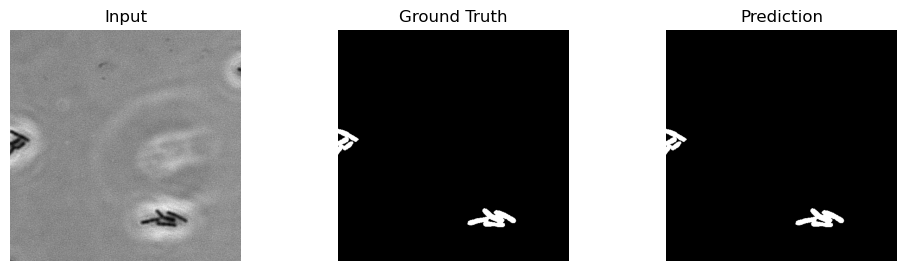

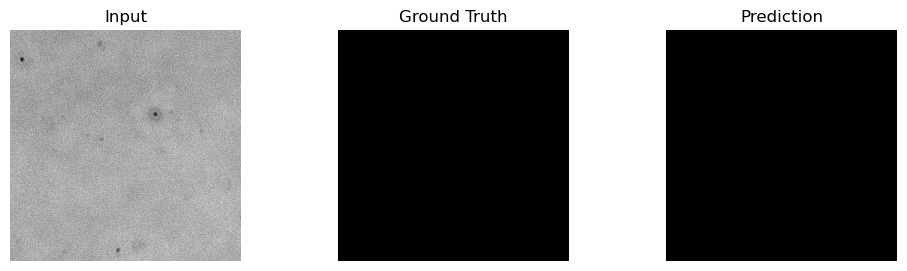

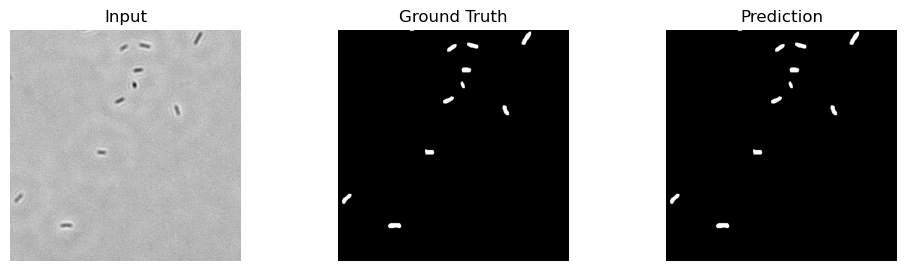

In [12]:
import matplotlib.pyplot as plt

num_examples = 10
for i in range(num_examples):
    plt.figure(figsize=(12, 3))

    # Input image
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[i].squeeze(), cmap="gray")
    plt.title("Input")
    plt.axis("off")

    # Ground truth
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(1, 3, 3)
    plt.imshow(y_val[i].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()


In [42]:
import numpy as np
print("y_val unique:", np.unique(y_val[:200]))


y_val unique: [0. 1.]


In [43]:
print(X_val.min(), X_val.max(), X_val.dtype)


19 255 uint8


In [45]:
import tensorflow as tf
import numpy as np

# Make sure y_pred exists
y_pred = model.predict(X_val, batch_size=2)

# Convert to tensors
y_true_tf = tf.convert_to_tensor(y_val, tf.float32)
y_pred_tf = tf.convert_to_tensor(y_pred, tf.float32)

# If masks are (N,H,W), add channel dim -> (N,H,W,1)
if len(y_true_tf.shape) == 3:
    y_true_tf = y_true_tf[..., tf.newaxis]
if len(y_pred_tf.shape) == 3:
    y_pred_tf = y_pred_tf[..., tf.newaxis]

# BCE per-pixel (no reduction)
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)

# This returns shape (N, H, W)
bce_map = bce(y_true_tf, y_pred_tf)

# Mean per sample -> shape (N,)
bce_loss = tf.reduce_mean(bce_map, axis=[1, 2])

def soft_iou_loss_per_sample(y_true, y_pred, smooth=1e-6):
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    iou = (inter + smooth) / (union + smooth)
    return 1.0 - iou  # shape (N,)

iou_loss = soft_iou_loss_per_sample(y_true_tf, y_pred_tf)

total = 0.5 * bce_loss + 0.5 * iou_loss

idx = int(tf.argmax(total).numpy())
print("Worst val index:", idx)
print("Total loss:", float(total[idx].numpy()))
print("BCE:", float(bce_loss[idx].numpy()))
print("IoU loss:", float(iou_loss[idx].numpy()))
print("y_true unique:", np.unique(y_val[idx]))


108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Worst val index: 200
Total loss: 0.5069097280502319
BCE: 0.013819469138979912
IoU loss: 1.0
y_true unique: [0.]


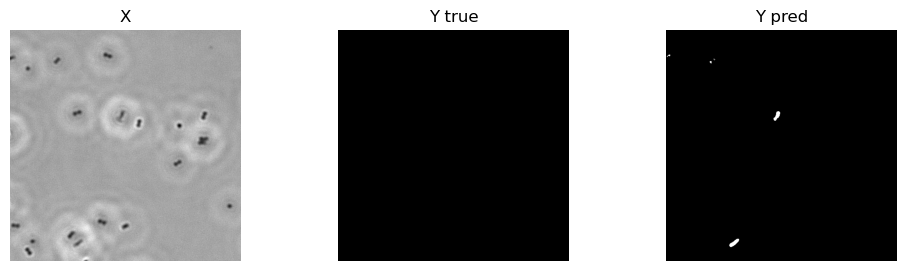

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); plt.imshow(X_val[idx].squeeze(), cmap="gray"); plt.title("X"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(y_val[idx].squeeze(), cmap="gray"); plt.title("Y true"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow((y_pred[idx].squeeze() > 0.5), cmap="gray"); plt.title("Y pred"); plt.axis("off")
plt.show()


In [3]:
import tensorflow as tf

model_path = "/home/local2/huili/Bacteria ID/Sabita/best_unet.keras"
model = tf.keras.models.load_model(model_path, compile=False)
print("Loaded model:", model_path)
print("Input shape:", model.input_shape)


Loaded model: /home/local2/huili/Bacteria ID/Sabita/best_unet.keras
Input shape: (None, 512, 512, 1)


In [15]:
from tensorflow.keras.models import load_model

Model = load_model("/home/local2/huili/Bacteria ID/Sabita/best_unet3.keras", compile=False)
Model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 256, 256,  │    131,200 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 256, 256,  │    295,040 │ concatenate[0][0

 Total params: 1,864,257 (7.11 MB)

 Trainable params: 1,862,977 (7.11 MB)

 Non-trainable params: 1,280 (5.00 KB)

Processing Images: 100%|██████████| 1/1 [00:00<00:00, 15.33it/s]


Processing Image_629220250530PH.tif: Image shape (2076, 3088), Mask shape (2076, 3088, 3)
Final Image Patches Shape: (77, 512, 512)
Final Mask Patches Shape: (77, 512, 512, 3)
Image Patches Shape after expand_dims: (77, 512, 512, 1)
Mask Patches Shape after expand_dims: (77, 512, 512, 3, 1)


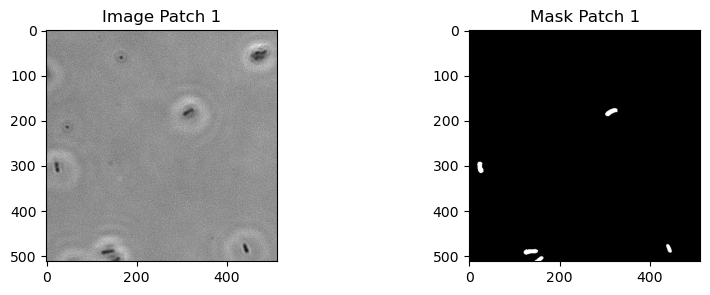

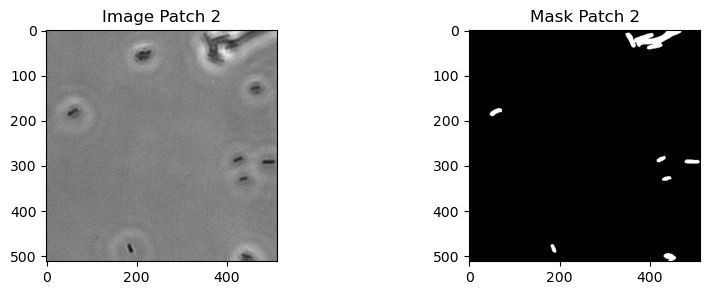

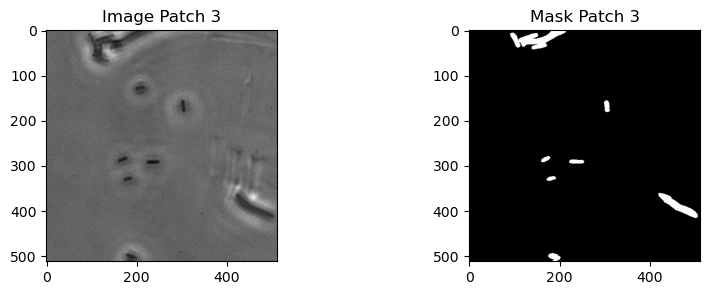

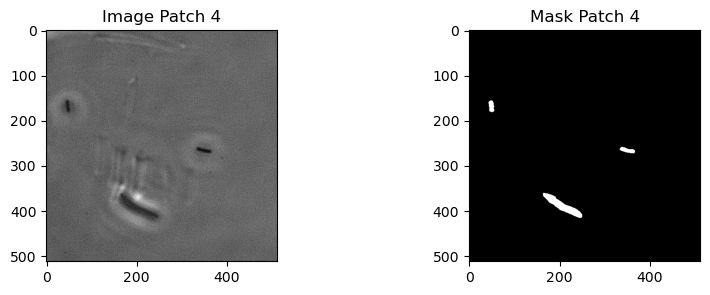

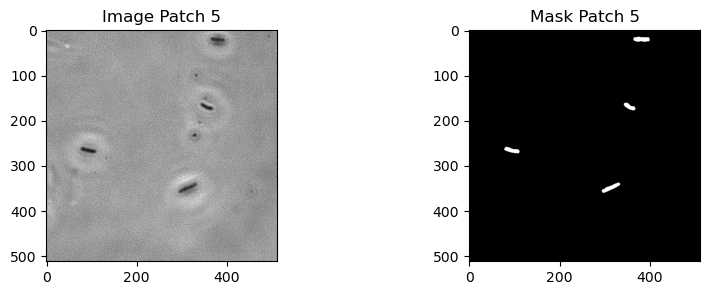

In [40]:
eval_folder = '/home/local2/huili/Bacteria ID/Sabita/Training data/5th/Evaluate'
eval_mask_folder = '/home/local2/huili/Bacteria ID/Sabita/Training data/5th/Evaluate_mask'
# X_test = load_dataset(eval_folder)
X_test, y_test = load_dataset(eval_folder, eval_mask_folder)

In [41]:
prediction_list = []
for index in range(77):
    prediction = Model.predict(np.expand_dims(X_test[index], axis=0))
    binary_prediction = (prediction > 0.5).astype(int)
    # plt.imshow(binary_prediction[0].squeeze(), cmap='gray')

    prediction_list.append(binary_prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━

In [22]:

# Calculate the number of rows and columns based on the dimensions of the original image
flag = 0
count = 0
initial = 1
for img in range(77):
    col = 2076//256
    row = 3088//256
    if count == 0:
        row_combined = prediction_list[img][0]
        count+=1
    elif count < row:
        row_combined = np.hstack((row_combined,prediction_list[img][0]))
        count+=1

    if (count==row) & (initial == 1):
        final_image = row_combined
        count = 0
        initial = 0
    elif (count==row):
        final_image = np.vstack((final_image,row_combined))
        count = 0


In [ ]:
import numpy as np

H, W = 2076, 3088  

ph, pw = 512, 512
sh, sw = 256, 256

n_rows = (H - ph) // sh + 1
n_cols = (W - pw) // sw + 1

sum_img = np.zeros((H, W), dtype=np.float32)
weight  = np.zeros((H, W), dtype=np.float32)

for i in range(len(prediction_list)):
    r = i // n_cols
    c = i %  n_cols

    y = r * sh
    x = c * sw

    patch = prediction_list[i][0]
    if patch.ndim == 3 and patch.shape[-1] == 1:
        patch = patch[..., 0]

    sum_img[y:y+ph, x:x+pw] += patch.astype(np.float32)
    weight[y:y+ph, x:x+pw] += 1.0

final_image = sum_img / np.maximum(weight, 1e-8)

#print("Original shape:", original_image.shape)
print("Reconstructed shape:", final_image.shape)
print("Expected patches:", n_rows * n_cols, "Got:", len(prediction_list))


Reconstructed shape: (2076, 3088)
Expected patches: 77 Got: 77


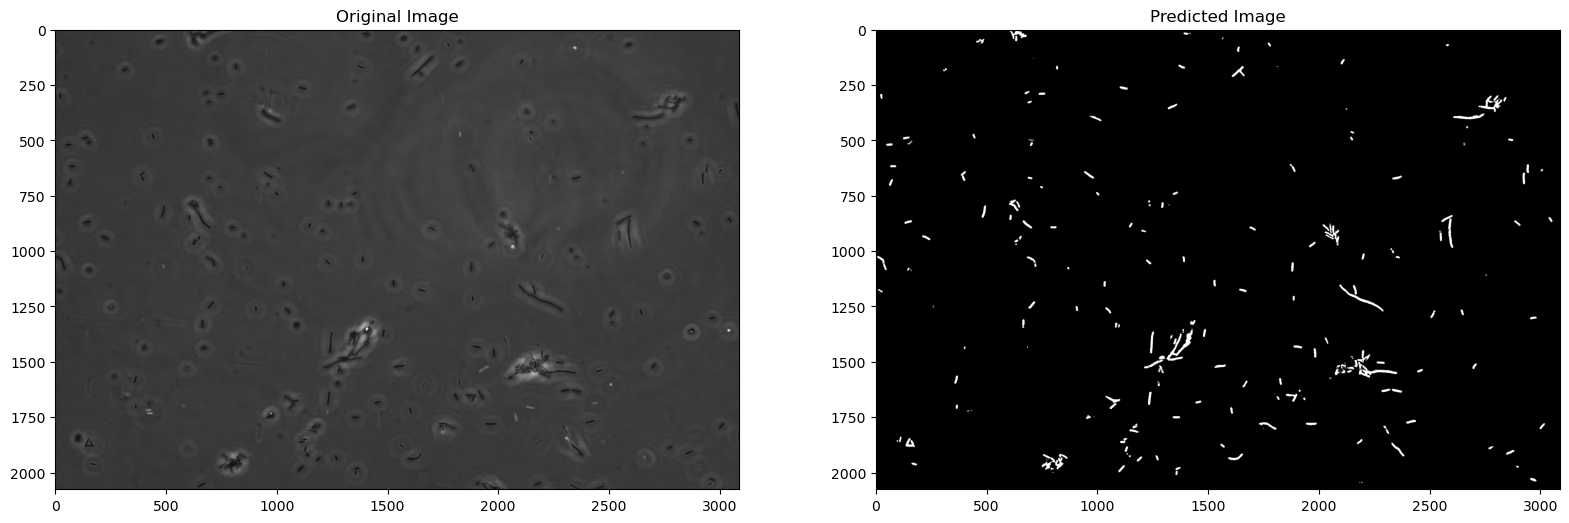

In [44]:
#test_image_mask_path = '/home/local2/huili/Image_112620241031_mask.tiff'
test_image_path = '/home/local2/huili/Bacteria ID/Sabita/Training data/5th/Evaluate/Image_629220250530PH.tif'
# mask = load_tiff_image(test_image_mask_path)
original = load_tiff_image(test_image_path)
# final_image = Model.predict(original)
plt.figure(figsize=(30, 20))

plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(original.squeeze(), cmap='gray')

plt.subplot(1, 3, 2)
plt.title('Predicted Image')
plt.imshow(final_image.squeeze(), cmap='gray')

# plt.subplot(1, 3, 3)
# plt.title('Original mask')
# plt.imshow(mask.squeeze(), cmap='gray')

plt.show()